# Sales & Demand Forecasting for Businesses
## Future Interns - Machine Learning Task 1

This project builds a Machine Learning model to forecast future retail sales using historical business data.  
The goal is to help businesses plan inventory, manage cash flow, prepare staffing, and avoid overstocking or stock shortages.

## 1. Import Required Libraries


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load Dataset

In [55]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Dataset Information

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 4. Check Missing Values


In [57]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 5. Statistical Summary

In [58]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 6. Data Cleaning & Time-Series Preparation

The dataset is cleaned by removing duplicate records and converting the Order Date column into datetime format.

Monthly sales values are then aggregated to prepare the dataset for forecasting analysis.

In [59]:
df = df.drop_duplicates()

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


## 7. Monthly Sales Trend Visualization

This visualization helps identify sales growth patterns, trends, and seasonality over time.


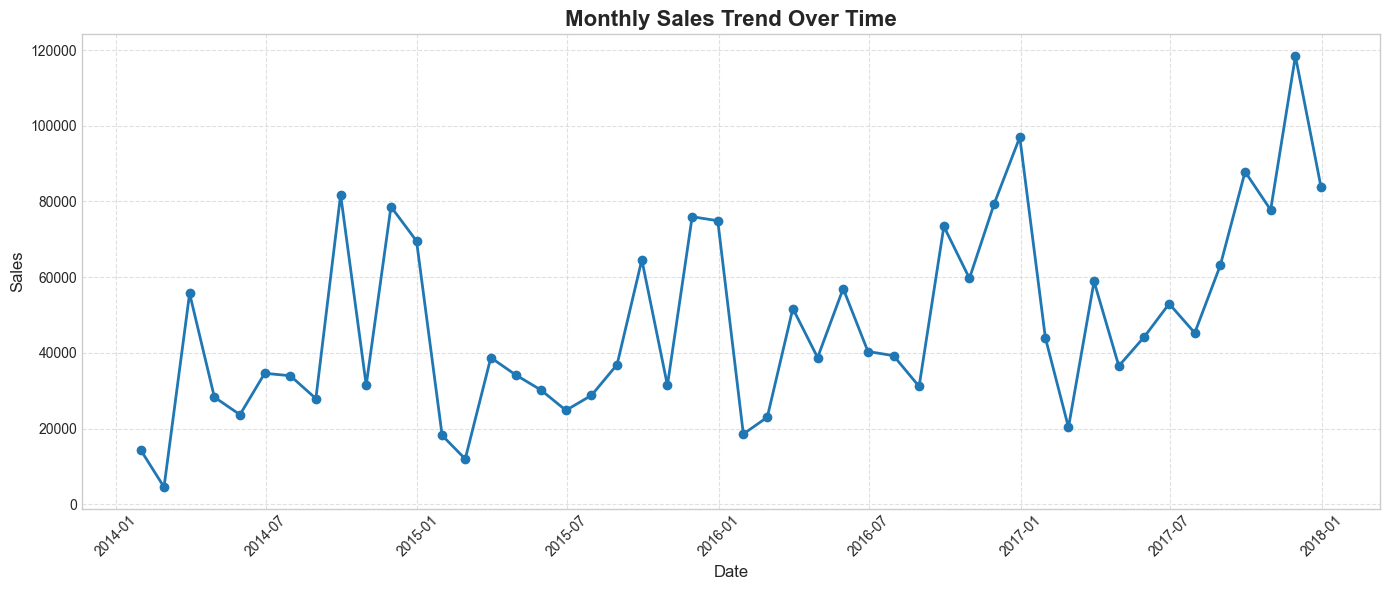

In [60]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visuals/monthly_sales_trend.png", dpi=300)
plt.show()

## 8. Feature Engineering

Time-based features are created to help the Machine Learning model understand trends and seasonality.

In [61]:
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month
monthly_sales["Year"] = monthly_sales["Order Date"].dt.year
monthly_sales["Time_Index"] = range(len(monthly_sales))

monthly_sales.head()

,Order Date,Sales,Month,Year,Time_Index
0,2014-01-31,14236.895,1,2014,0
1,2014-02-28,4519.892,2,2014,1
2,2014-03-31,55691.009,3,2014,2
3,2014-04-30,28295.345,4,2014,3
4,2014-05-31,23648.287,5,2014,4



## 9. Train-Test Split

The dataset is split in time order so the model learns from past sales and is tested on later sales.

In [62]:
X = monthly_sales[["Month", "Year", "Time_Index"]]
y = monthly_sales["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (38, 3)
Testing data: (10, 3)


## 10. Model Training

A Linear Regression model is used to forecast sales based on month, year, and trend index.

In [63]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 11. Sales Prediction

In [64]:
y_pred = model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

prediction_results

,Actual Sales,Predicted Sales
0,58872.3528,37696.0
1,36521.5361,42496.0
2,44261.1102,47360.0
3,52981.7257,52224.0
4,45264.4160,57088.0
5,63120.8880,61952.0
6,87866.6520,66816.0
7,77776.9232,71680.0
8,118447.8250,76544.0
9,83829.3188,81344.0


## 12. Model Evaluation

The forecasting model is evaluated using MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

In [65]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 11553.66232
Root Mean Squared Error (RMSE): 16964.3232169548


## 13. Actual vs Predicted Sales Visualization

This graph compares actual sales values with predicted sales values generated by the model.

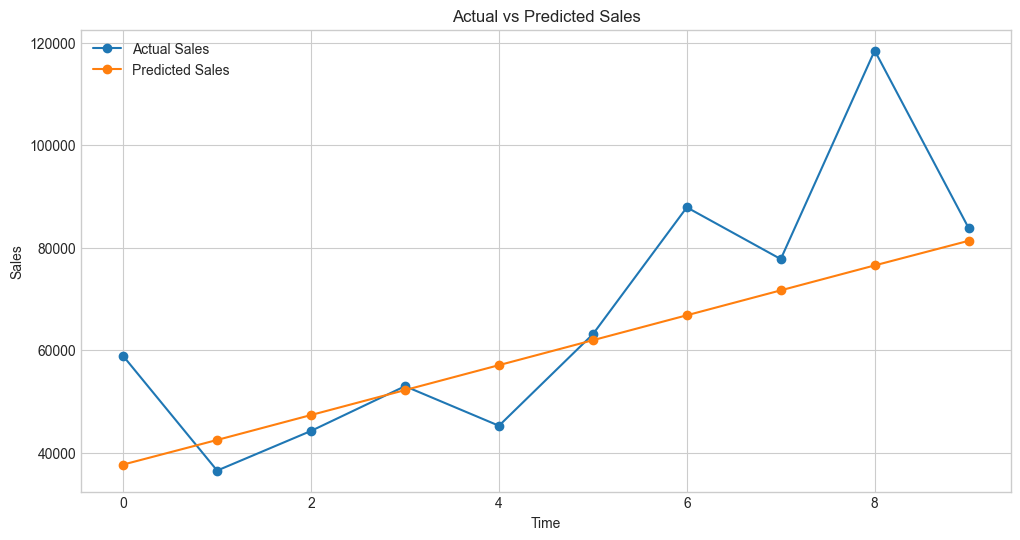

In [66]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    y_pred,
    label="Predicted Sales",
    marker="o"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## 14. Future Sales Forecasting

The model is used to predict future monthly sales for upcoming months.

In [67]:
future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="ME"
)

future_df = pd.DataFrame({
    "Month": future_dates.month,
    "Year": future_dates.year,
    "Time_Index": range(
        len(monthly_sales),
        len(monthly_sales) + 6
    )
})

future_predictions = model.predict(future_df)

future_results = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

future_results

,Date,Forecasted Sales
0,2018-01-31,33472.0
1,2018-02-28,38272.0
2,2018-03-31,43136.0
3,2018-04-30,48000.0
4,2018-05-31,52864.0
5,2018-06-30,57728.0


## 15. Future Sales Forecast Visualization

This visualization shows predicted future sales trends for business planning and decision-making.

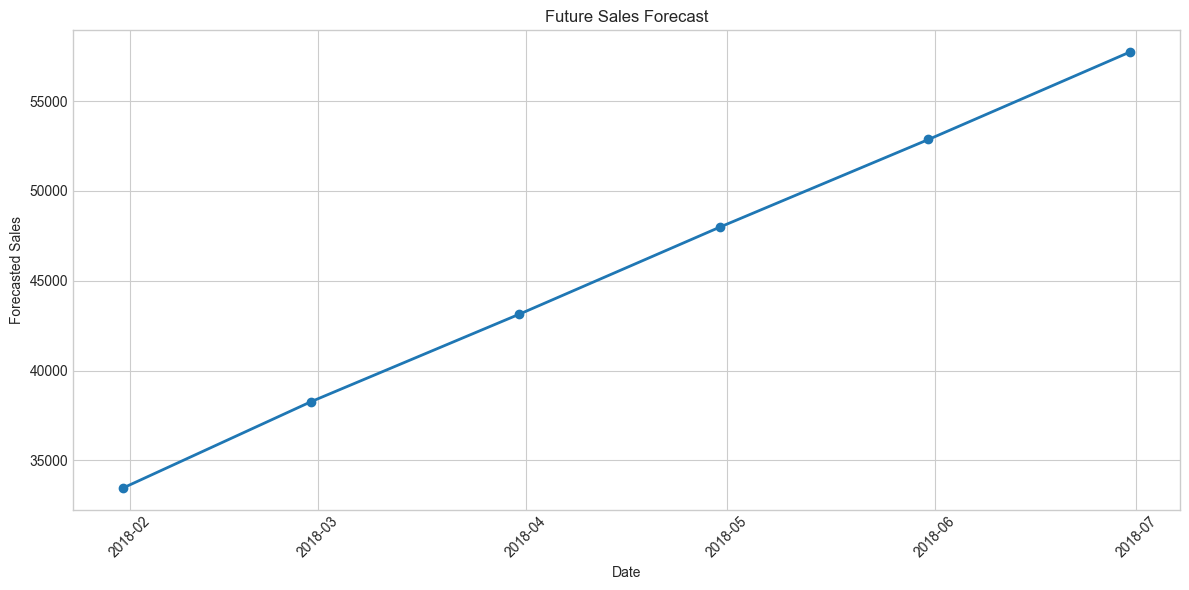

In [68]:
plt.figure(figsize=(12,6))

plt.plot(
    future_results["Date"],
    future_results["Forecasted Sales"],
    marker="o",
    linewidth=2
)

plt.title("Future Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig("../visuals/future_sales_forecast.png")

plt.show()

## Category-wise Sales

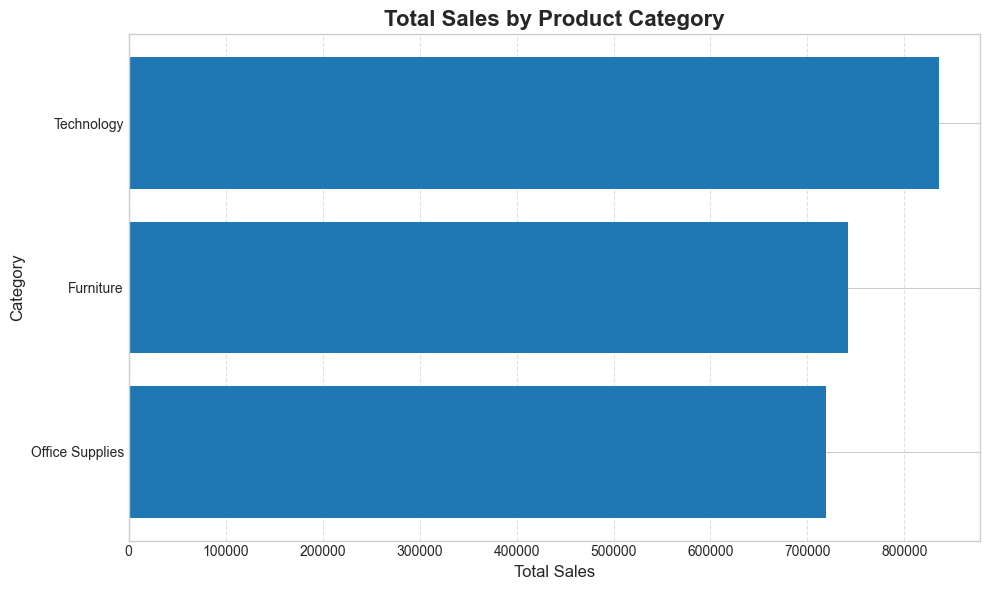

In [69]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

plt.figure(figsize=(10,6))

plt.barh(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../visuals/category_sales.png", dpi=300)
plt.show()

## Region-wise Sales

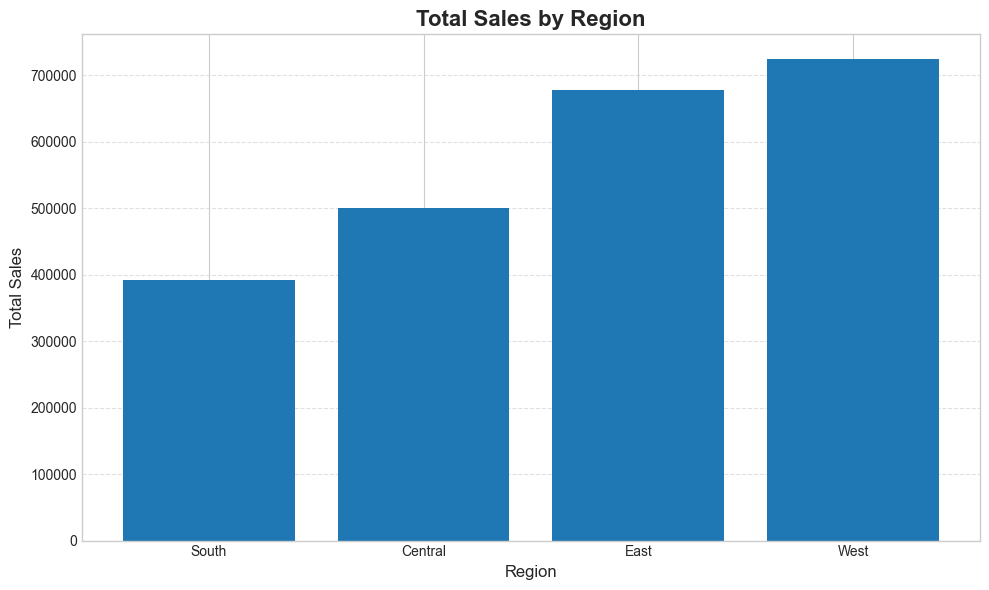

In [70]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(10,6))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../visuals/region_sales.png", dpi=300)
plt.show()

## 16. Business Insights & Conclusion

### Key Insights
- Sales show noticeable fluctuations across different months, indicating seasonal business trends.
- The forecasting model successfully identifies overall sales patterns from historical data.
- Predicted future sales can help businesses prepare inventory and staffing requirements.

### Business Impact
This forecasting system can help:
- improve inventory planning
- reduce overstocking and stock shortages
- support financial and staffing decisions
- improve demand forecasting strategies

### Conclusion
Machine Learning forecasting techniques can support real-world business decision-making by transforming historical sales data into actionable future insights.